<a href="https://colab.research.google.com/github/Fushionek/MLTraining/blob/main/Stroke_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [10]:
import kagglehub

path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/stroke-prediction-dataset


In [11]:
df_raw = pd.DataFrame(pd.read_csv(path + "/healthcare-dataset-stroke-data.csv"))
df_raw

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [13]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [14]:
df_raw.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [15]:
df_raw = df_raw.drop('id',axis=1)

In [17]:
df_raw

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [18]:
df_raw = df_raw.dropna(subset=['bmi'])

In [22]:
df_raw.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,4909.000000,4909.000000,4909.000000,4909.000000,4909.000000,4909.000000
mean,42.865374,0.091872,0.049501,105.305150,28.893237,0.042575
std,22.555115,0.288875,0.216934,44.424341,7.854067,0.201917
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.070000,23.500000,0.000000
50%,44.000000,0.000000,0.000000,91.680000,28.100000,0.000000
75%,60.000000,0.000000,0.000000,113.570000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


/tmp/ipykernel_15447/497628168.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='stroke', ax=axes[0], palette='Set2')


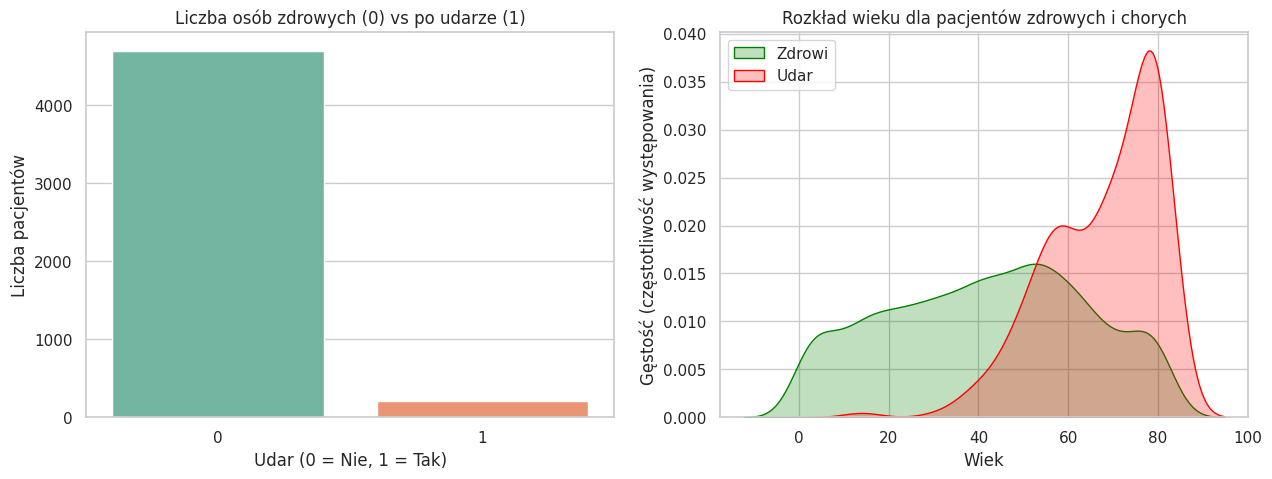

In [25]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=df_raw, x='stroke', ax=axes[0], palette='Set2')
axes[0].set_title('Liczba osób zdrowych (0) vs po udarze (1)')
axes[0].set_ylabel('Liczba pacjentów')
axes[0].set_xlabel('Udar (0 = Nie, 1 = Tak)')
sns.kdeplot(data=df_raw[df_raw['stroke'] == 0], x='age', fill=True, color="green", label='Zdrowi', ax=axes[1])
sns.kdeplot(data=df_raw[df_raw['stroke'] == 1], x='age', fill=True, color="red", label='Udar', ax=axes[1])
axes[1].set_title('Rozkład wieku dla pacjentów zdrowych i chorych')
axes[1].set_xlabel('Wiek')
axes[1].set_ylabel('Gęstość (częstotliwość występowania)')
axes[1].legend()
plt.show()

In [26]:
df_encoded = pd.get_dummies(df_raw,drop_first=True).astype(float)

In [27]:
df_encoded

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0.0,1.0,228.69,36.6,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
2,80.0,0.0,1.0,105.92,32.5,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,49.0,0.0,0.0,171.23,34.4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4,79.0,1.0,0.0,174.12,24.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5,81.0,0.0,0.0,186.21,29.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5104,13.0,0.0,0.0,103.08,18.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5106,81.0,0.0,0.0,125.20,40.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
5107,35.0,0.0,0.0,82.99,30.6,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5108,51.0,0.0,0.0,166.29,25.6,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


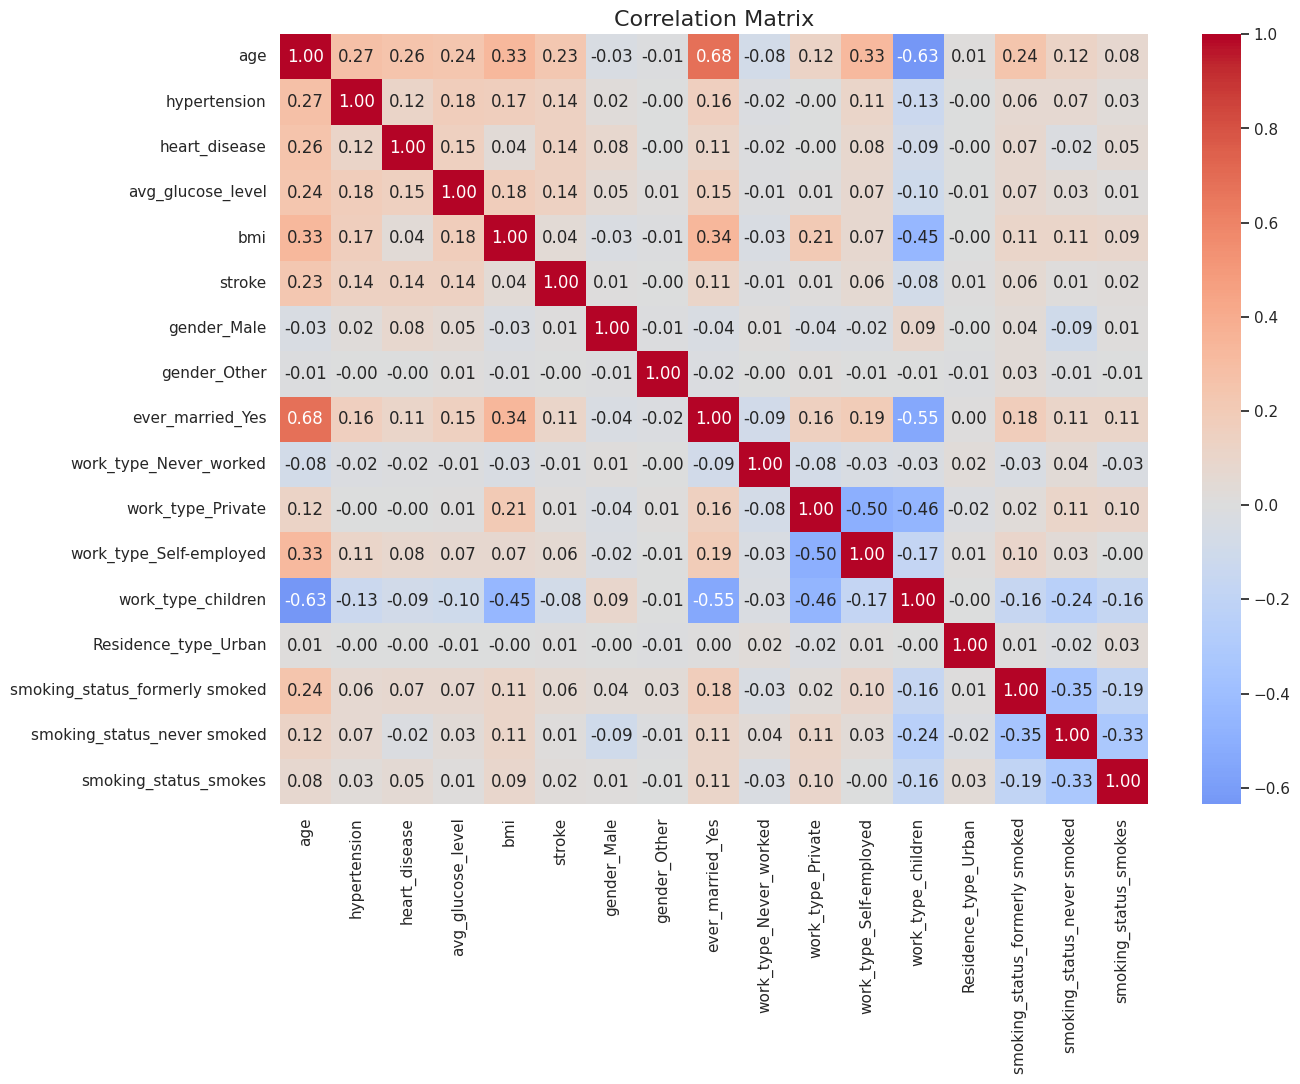

In [28]:
plt.figure(figsize=(14, 10))

sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)

plt.title("Correlation Matrix", fontsize=16)
plt.show()

In [29]:
X = df_encoded.drop('stroke',axis=1)
y = df_encoded['stroke']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape[0]

3927

In [32]:
X_test.shape[0]

982

In [33]:
model = LogisticRegression(class_weight='balanced', max_iter=1000,random_state=42)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.98      0.76      0.86       940
         1.0       0.11      0.69      0.20        42

    accuracy                           0.76       982
   macro avg       0.55      0.73      0.53       982
weighted avg       0.94      0.76      0.83       982



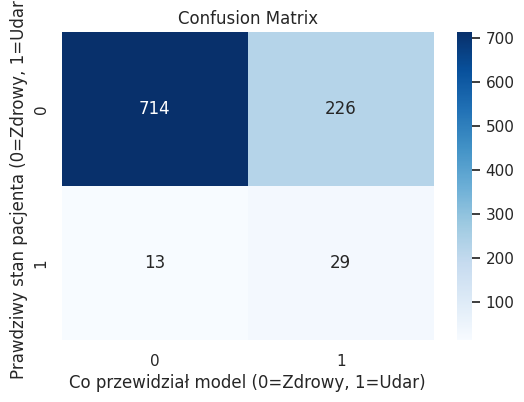

In [34]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Co przewidział model (0=Zdrowy, 1=Udar)')
plt.ylabel('Prawdziwy stan pacjenta (0=Zdrowy, 1=Udar)')
plt.show()

In [37]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

In [38]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [40]:
print(f"Before SMOTE: {sum(y_train == 1)}")
print(f"After SMOTE: {sum(y_train_resampled == 1)}")

Before SMOTE: 167
After SMOTE: 3760


In [47]:
model_smote = RandomForestClassifier(n_estimators=100,max_depth=8, random_state=42)
model_smote.fit(X_train_resampled, y_train_resampled)
probability = model_smote.predict_proba(X_test)[:,1]
y_pred_smote = (probability > 0.3).astype(int)
print(classification_report(y_test,y_pred_smote))

              precision    recall  f1-score   support

         0.0       0.98      0.85      0.91       940
         1.0       0.15      0.60      0.24        42

    accuracy                           0.84       982
   macro avg       0.56      0.72      0.57       982
weighted avg       0.94      0.84      0.88       982



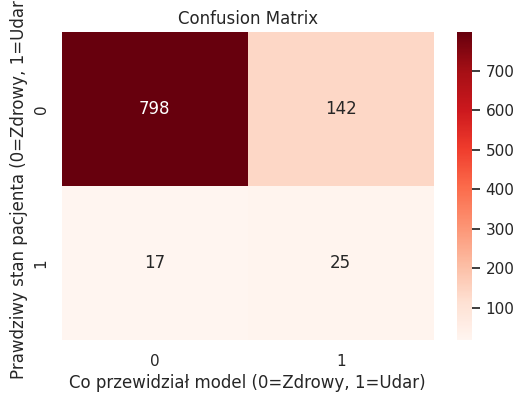

In [48]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_smote), annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix')
plt.xlabel('Co przewidział model (0=Zdrowy, 1=Udar)')
plt.ylabel('Prawdziwy stan pacjenta (0=Zdrowy, 1=Udar)')
plt.show()

In [52]:
probability = model_smote.predict_proba(X_test)[:,1]
y_pred_smote = (probability > 0.1).astype(int)
print(classification_report(y_test,y_pred_smote))

              precision    recall  f1-score   support

         0.0       0.99      0.61      0.75       940
         1.0       0.09      0.83      0.16        42

    accuracy                           0.62       982
   macro avg       0.54      0.72      0.45       982
weighted avg       0.95      0.62      0.73       982



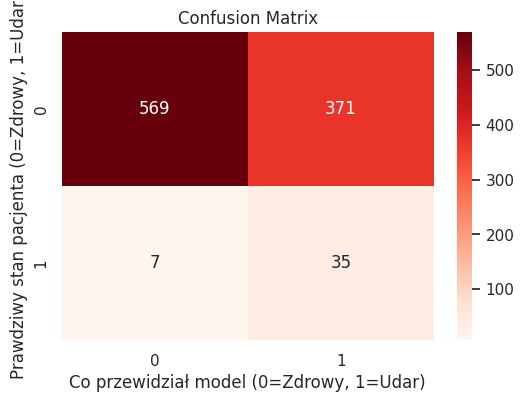

In [53]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_smote), annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix')
plt.xlabel('Co przewidział model (0=Zdrowy, 1=Udar)')
plt.ylabel('Prawdziwy stan pacjenta (0=Zdrowy, 1=Udar)')
plt.show()

In [60]:
dane_pacjenta = pd.DataFrame([{
    'age': 65.0,
    'hypertension': 1,
    'heart_disease': 1,
    'avg_glucose_level': 120.5,
    'bmi': 28.5,
    'gender_Male': 1,
    'gender_Other': 0,
    'ever_married_Yes': 1,
    'work_type_Never_worked': 0,
    'work_type_Private': 1,
    'work_type_Self-employed': 0,
    'work_type_children': 0,
    'Residence_type_Urban': 1,
    'smoking_status_formerly smoked': 0,
    'smoking_status_never smoked': 0,
    'smoking_status_smokes': 1
}])

dane_pacjenta = dane_pacjenta.reindex(columns=X_train.columns, fill_value=0)

prob = model_smote.predict_proba(dane_pacjenta)[0, 1]

alert = 0.15

print(f"Obliczone ryzyko udaru: {prob * 100:.1f}%\n")

if prob >= alert:
    print("Ryzyko przekracza bezpieczny próg.")
else:
    print("Wynik w normie.")


Obliczone ryzyko udaru: 62.7%

Ryzyko przekracza bezpieczny próg.
